# Neural Network from Scratch

This notebook implements a small feedforward neural network **from scratch using NumPy**.

The goal is to make the main building blocks of a neural network explicit:

- forward propagation
- ReLU activation
- mean squared error used as loss
- backpropagation
- gradient descent
- evaluation on unseen test data

### Architecture

$$
2\ \text{inputs} \rightarrow 8\ \text{hidden neurons (ReLU)} \rightarrow 1\ \text{output}
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

## 1. Generate synthetic regression data

The target contains a quadratic term and an interaction term:

$$
y = 1.5x_1^2 + 0.8x_2 - 0.4x_1x_2 + \varepsilon
$$

with Gaussian noise $\varepsilon$. This creates a simple nonlinear regression problem.

In [2]:
data_rng = np.random.default_rng(42)

n_samples = 600

X = data_rng.uniform(-2, 2, size=(n_samples, 2))
noise = data_rng.normal(0, 0.20, size=n_samples)

y = (
    1.5 * X[:, 0] ** 2
    + 0.8 * X[:, 1]
    - 0.4 * X[:, 0] * X[:, 1]
    + noise
).reshape(-1, 1)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (600, 2)
y shape: (600, 1)


## 2. Activation function

The hidden layer uses the ReLU activation function:

$$
\operatorname{ReLU}(z) = \max(0, z)
$$


In [ ]:
def relu(z):
    """Apply the ReLU activation function elementwise."""
    return np.maximum(0, z)

## 3. Initialize the network

Weights are initialized randomly, while biases start at zero.

A dedicated random seed makes the initialization reproducible and independent of the random numbers used to generate the dataset.

In [4]:
INPUT_SIZE = 2
HIDDEN_SIZE = 8
OUTPUT_SIZE = 1


def initialize_parameters(input_size, hidden_size, output_size, seed=123):
    """Initialize weights and biases for a one-hidden-layer network."""
    rng = np.random.default_rng(seed)

    W1 = rng.uniform(-1, 1, size=(input_size, hidden_size))
    b1 = np.zeros((1, hidden_size))

    W2 = rng.uniform(-1, 1, size=(hidden_size, output_size))
    b2 = np.zeros((1, output_size))

    return W1, b1, W2, b2

## 4. Forward pass

For each sample, the network computes

$$
Z_1 = XW_1 + b_1
$$

$$
A_1 = \operatorname{ReLU}(Z_1)
$$

$$
\hat{y} = A_1W_2 + b_2
$$

`Z1` and `A1` are returned because they are needed during backpropagation.

In [5]:
def forward(X, W1, b1, W2, b2):
    """Perform a forward pass through the network."""
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    y_hat = A1 @ W2 + b2

    return Z1, A1, y_hat

### Sanity check

Before training, verify the tensor shapes and the behavior of ReLU.

In [6]:
W1, b1, W2, b2 = initialize_parameters(
    INPUT_SIZE, HIDDEN_SIZE, OUTPUT_SIZE
)

Z1, A1, y_hat = forward(X, W1, b1, W2, b2)

assert Z1.shape == (n_samples, HIDDEN_SIZE)
assert A1.shape == (n_samples, HIDDEN_SIZE)
assert y_hat.shape == (n_samples, OUTPUT_SIZE)
assert np.all(A1 >= 0)

print("All forward-pass checks passed.")

All forward-pass checks passed.


## 5. Backpropagation

For mean squared error,

$$
L = \frac{1}{n}\sum_i (\hat{y}_i-y_i)^2
$$

the gradient with respect to the predictions is

$$
\frac{\partial L}{\partial \hat{y}}
= \frac{2}{n}(\hat{y}-y).
$$

The remaining gradients are propagated backward through the output layer, ReLU, and the first linear layer.

In [7]:
def backward(X, y, y_hat, Z1, A1, W2):
    """Compute gradients for all trainable parameters."""
    n_samples = X.shape[0]

    # Loss -> output
    dL_dy_hat = (2 / n_samples) * (y_hat - y)

    # Output layer
    dW2 = A1.T @ dL_dy_hat
    db2 = np.sum(dL_dy_hat, axis=0, keepdims=True)
    dA1 = dL_dy_hat @ W2.T

    # ReLU
    dZ1 = dA1 * (Z1 > 0)

    # First layer
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2

## 6. Training

The network is trained with full-batch gradient descent.

`loss_history` is created **inside** the training function, so every training run starts with an empty history.

In [8]:
def train(
    X_train,
    y_train,
    epochs=5000,
    learning_rate=0.0001,
    seed=123,
    print_every=500,
):
    """Train the network and return learned parameters and loss history."""
    W1, b1, W2, b2 = initialize_parameters(
        X_train.shape[1], HIDDEN_SIZE, y_train.shape[1], seed=seed
    )

    loss_history = []

    for epoch in range(epochs):
        Z1, A1, y_hat = forward(X_train, W1, b1, W2, b2)

        loss = np.mean((y_hat - y_train) ** 2)
        loss_history.append(loss)

        dW1, db1, dW2, db2 = backward(
            X_train, y_train, y_hat, Z1, A1, W2
        )

        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

        if print_every and (epoch % print_every == 0 or epoch == epochs - 1):
            print(f"Epoch {epoch:4d} | MSE: {loss:.6f}")

    return W1, b1, W2, b2, loss_history

## 7. Prediction and visualization helpers

In [9]:
def predict(X, W1, b1, W2, b2):
    """Return network predictions for new input data."""
    _, _, y_hat = forward(X, W1, b1, W2, b2)
    return y_hat


def plot_loss(loss_history):
    """Plot training loss over epochs."""
    plt.figure(figsize=(8, 5))
    plt.plot(loss_history)
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.title("Training loss")
    plt.grid(True)
    plt.show()


def plot_predictions(y_true, y_pred):
    """Plot predicted values against true target values."""
    lower = min(y_true.min(), y_pred.min())
    upper = max(y_true.max(), y_pred.max())

    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.7)
    plt.plot([lower, upper], [lower, upper], linestyle="--")
    plt.xlabel("True y")
    plt.ylabel("Predicted y")
    plt.title("Predictions vs. true values")
    plt.grid(True)
    plt.show()

## 8. Train/test split and evaluation

The model is trained only on the training set. The learned parameters are then applied to unseen test data without any further updates.

Epoch    0 | MSE: 11.509531
Epoch  500 | MSE: 6.504872
Epoch 1000 | MSE: 4.262387
Epoch 1500 | MSE: 3.239566
Epoch 2000 | MSE: 2.761813
Epoch 2500 | MSE: 2.505545
Epoch 3000 | MSE: 2.333300
Epoch 3500 | MSE: 2.193798
Epoch 4000 | MSE: 2.060464
Epoch 4500 | MSE: 1.935063
Epoch 4999 | MSE: 1.821823


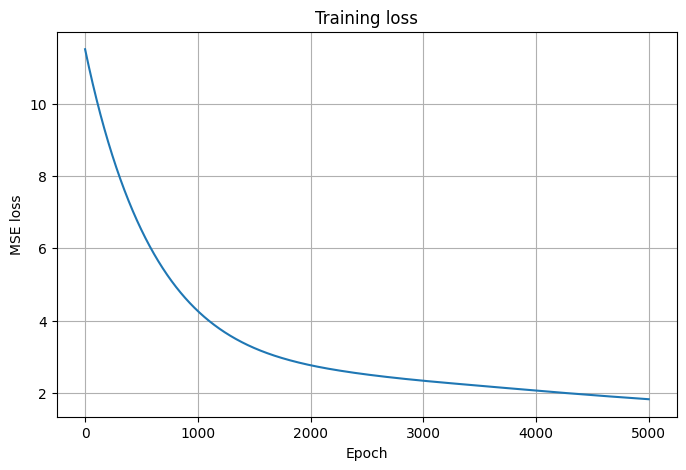

Test MAE: 1.1763
Test MSE: 1.9057


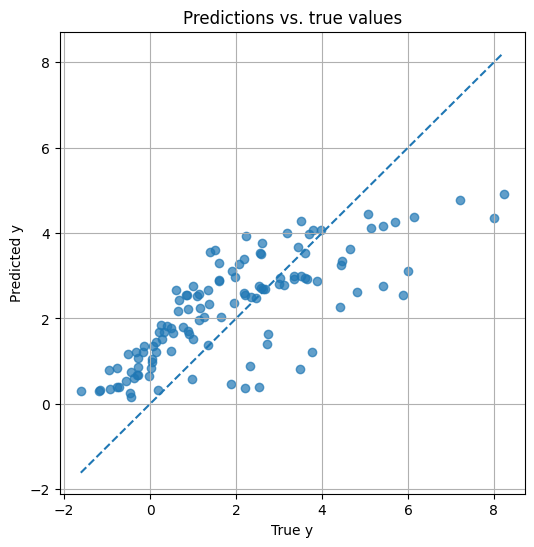

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

W1, b1, W2, b2, loss_history = train(
    X_train,
    y_train,
    epochs=5000,
    learning_rate=0.0001,
)

plot_loss(loss_history)

y_test_pred = predict(X_test, W1, b1, W2, b2)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"Test MAE: {test_mae:.4f}")
print(f"Test MSE: {test_mse:.4f}")

plot_predictions(y_test, y_test_pred)

## Interpretation: 
The model captures the general nonlinear relationship in the data, with a mean absolute error of approximately 1.18 target units. However, the prediction plot shows that the network tends to overestimate some low target values and underestimate larger target values. The predictions are compressed toward the center of the target range, suggesting that the current network or training setup does not yet fully capture the extremes of the underlying function.

## Next steps

Possible extensions:

- numerical gradient checking
- comparison with an equivalent PyTorch model
- mini-batch gradient descent
- additional hidden layers
